Declaration

The analysis we have conducted adopts a causal framework which estimates the effect of COVID-19 lockdown policies on unemployment in Victoria relative to New South Wales. The analysis exploits the differences in lockdown intensity across states over time, using NSW as a control group to approximate the counterfactual path of unemployment in Victoria absent stricter lockdowns. The validity of our approach depends entirely on the assumption that NSW does provide a credible counterfactual for Victoria in the absence of differential policy responses.

Econometric Specification

The main econometric specification is a Difference-in-Differences (DiD) model:
Where  is the unemployment rate in states at time t.  is the indicator equal to 1 for Victoria and 0 for New South Wales.  is the indicator equal to 1 for the period after March 2020 and 0 otherwise. The interaction term  is the Difference-in-Differences estimator.
The sample that we have used is only restricted to January 2016 to December 2021 which captures both the pre-COVID period and the acute lockdown period. We have used the Ordinary Least Squares (OLS) for this model with heteroskedasticity-robust (HC1) standard errors.

                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     17.69
Date:                Tue, 05 May 2026   Prob (F-statistic):           9.01e-10
Time:                        10:12:28   Log-Likelihood:                -148.98
No. Observations:                 142   AIC:                             306.0
Df Residuals:                     138   BIC:                             317.8
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7900      0.055     87.223      0.0

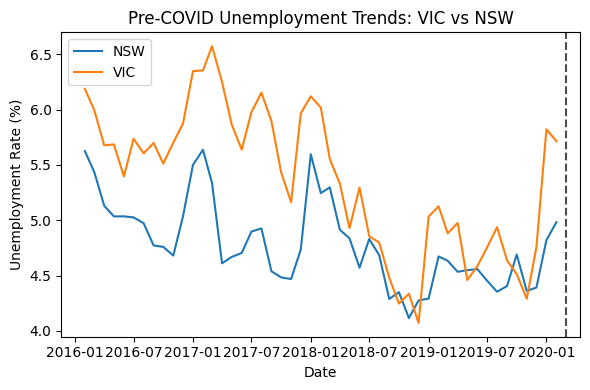

                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     17.72
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.06e-10
Time:                        10:12:29   Log-Likelihood:                -309.98
No. Observations:                 242   AIC:                             628.0
Df Residuals:                     238   BIC:                             641.9
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7900      0.055     87.744      0.0

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import matplotlib.pyplot as plt

# =========================
# 1. Load + reshape data
# =========================

df = pd.read_csv('../data/clean/merged_stringency_unemployment.csv')
df = df.rename(columns={
    'VIC_Unemployment': 'VIC_unemployment',
    'NSW_Unemployment': 'NSW_unemployment',
    'VIC_Stringency': 'VIC_stringency',
    'NSW_Stringency': 'NSW_stringency'
})

df['Date'] = pd.to_datetime(df['Date'])

# Long panel format
vic = df[['Date', 'VIC_unemployment', 'VIC_stringency']].copy()
vic['state'] = 'VIC'
vic = vic.rename(columns={'VIC_unemployment': 'unemployment',
                          'VIC_stringency': 'stringency'})

nsw = df[['Date', 'NSW_unemployment', 'NSW_stringency']].copy()
nsw['state'] = 'NSW'
nsw = nsw.rename(columns={'NSW_unemployment': 'unemployment',
                          'NSW_stringency': 'stringency'})

panel = pd.concat([vic, nsw], ignore_index=True)
panel = panel.dropna(subset=['unemployment', 'stringency']).copy()

# =========================
# 2. Restrict to acute causal window
# =========================
# Pre: 2016–Feb 2020
# Treatment: Mar 2020–Dec 2021
# Drop recovery period entirely

acute_panel = panel[
    (panel['Date'] >= '2016-01-01') &
    (panel['Date'] <= '2021-12-31')
].copy()

# =========================
# 3. Build DiD variables
# =========================

acute_panel['treated'] = (acute_panel['state'] == 'VIC').astype(int)
acute_panel['post'] = (acute_panel['Date'] >= '2020-03-01').astype(int)
acute_panel['did'] = acute_panel['treated'] * acute_panel['post']

# =========================
# 4. Acute DiD model
# =========================

model_did_acute = smf.ols(
    'unemployment ~ treated + post + did',
    data=acute_panel
).fit(cov_type='HC1')

print(model_did_acute.summary())

# =========================
# 5. Parallel trends test (pre-COVID only)
# =========================

pre = acute_panel[acute_panel['Date'] < '2020-03-01'].copy()
pre = pre.sort_values(['state', 'Date'])
pre['trend'] = pre.groupby('state').cumcount()

model_pretrend = smf.ols(
    'unemployment ~ trend * treated',
    data=pre
).fit(cov_type='HC1')

print(model_pretrend.summary())

# =========================
# 6. Visual pre-trend check
# =========================

plt.figure(figsize=(6, 4))
for s, g in pre.groupby('state'):
    g_sorted = g.sort_values('Date')
    plt.plot(g_sorted['Date'], g_sorted['unemployment'], label=s)

plt.axvline(pd.to_datetime('2020-03-01'), color='black', linestyle='--', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Pre-COVID Unemployment Trends: VIC vs NSW')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/pretrend_vic_nsw.png', dpi=300)
plt.show()

# =========================
# 7. Full-period DiD (for comparison only)
# =========================

full_panel = panel.copy()
full_panel['treated'] = (full_panel['state'] == 'VIC').astype(int)
full_panel['post'] = (full_panel['Date'] >= '2020-03-01').astype(int)
full_panel['did'] = full_panel['treated'] * full_panel['post']

model_did_full = smf.ols(
    'unemployment ~ treated + post + did',
    data=full_panel
).fit(cov_type='HC1')

print(model_did_full.summary())

# =========================
# 8. Summary table (acute vs full-period)
# =========================

results_causal = {
    'Acute DiD (2016–2021)': model_did_acute,
    'Full-period DiD': model_did_full
}

table_causal = summary_col(
    list(results_causal.values()),
    model_names=list(results_causal.keys()),
    stars=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}"
    }
)

print(table_causal)

with open('../outputs/regression_table_causal.txt', 'w') as f:
    f.write(table_causal.as_text())

Interpretation of main coefficients 

Across both the regressions, the coefficient on treated is positive and statistically significant (=0.58), which indicates that before the COVID-19, Victoria had an unemployment rate which was around 0.6 percentage points higher than New South Wales. The post coefficient captures the common shock that occurred from COVID-19: it is shown in the acute window model that it is positive (0.86), which shows that unemployment rose for both states after March 2020, whereas in the full-period model it becomes negative (-0.46), which reflects the later recovery phase where unemployment fell below pre-COVID levels. The coefficient on DiD (treated x post) is the key causal parameter, which is negative in both the models (-0.49 in the acute window; -0.29 in the full period), which indicates that Victoria’s unemployment rose less than New South Wales’s after March 2020 relative to their pre-COVID difference. However, in comparison to both regressions the DiD coefficient is statistically insignificant (p=0.114 and p=0.156), which means that we simply cannot reject the hypothesis that Victoria’s stricter lockdowns had no differential causal effect on the unemployment compared to NSW.


Threats to validity 

1. Differential Industry Composition


Victoria and New South Wales's difference in underlying industry structure acts as a major threat to the validity of our casual claim. Victoria boasts greater exposure to sectors such as hospitality, retail, international education and tourism, which were affected disproportionately by COVID-19 lockdown. Since these industries were already more vulnerable in Victoria, hence the result in the DiD estimate will be biased upward, therefore, overstating how the effect stricter lockdown had in unemployment. On the other hand, if NSW had greater exposure to the mentioned sectors, the estimate would conversely be biased downwards. Since industry composition isn’t controlled for in our regression model, and instead evolves slowly over time, this remains as a prominent source of omitted variable bias. 

2. Cross‑State Spillovers and Labour Mobility

Due to the economic spillovers between states, another key threat arises. We find that many workers move across borders, firms adjust their hiring and operations as a response to differing restrictions. If New South Wales were to absorb some of Victoria’s labour market shock- through displaced workers seeking employment or firms shifting activity – then the impact of unemployment in Victoria will appear somewhat smaller relative to NSW. The spillover effect biases the DiD estimate towards zero, which makes it much harder to detect a true treatment effect biases the DiD estimate towards zero, which again makes it harder to detect a true treatment effect even if Victoria’s stricter lockdowns did have any meaningful impact.

3. Measurement Error in Monthly Unemployment Data


Monthly unemployment data is estimated from surveys and not census and there the data is subject to sampling noise and measure error, specifically during periods of rapid economic change, such as COVID-19. Treatment effects appear smaller than they are in actuality because classical measurement error in the dependent variable estimates coefficients towards zero, causing a reduction in statistical significance. This goes in parallel with the statistically insignificant DiD coefficients in both of the regression models. This suggests sampling noise regarding unemployment may be masking underlying differences between VIC and NSW. 


Conclusion
The Difference-in-Differences results statistically show no significant evidence that the stricter COVID-19 lockdowns in Victoria had any differential impact on unemployment compared to New South Wales. Although the point suggests Victoria may have experienced a slightly smaller rise in unemployment, the effects are imprecisely estimated and simply cannot be interpreted as causal. The key threats to validity are ambiguous and are reinforced by differences in industry composition, cross-state spillovers, and measurement error in unemployment data - which also may obscure real underlying effects. In conclusion, these findings should and must be interpreted cautiously, because the available data and design simply limits our ability to draw strong causal conclusions. 
